In [34]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('All imports loaded.')

All imports loaded.


In [35]:
# from google.colab import drive
# drive.mount('/content/drive')

#  #Read fresh data
# df = pd.read_csv('/content/drive/MyDrive/Data/Test/full_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/data/full_data.csv')

In [36]:
# Basic cleaning
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.replace('?', np.nan)

# Clean column names
df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)).strip('_') for c in df.columns]

# Replace '?' with NaN
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip().replace('?', np.nan)

In [37]:
# Encode target
df['label'] = df['label'].str.strip().map({'- 50000.': 0, '50000+.': 1})

In [38]:
# Drop unnecessary columns
drop_cols = [
    'weight',
    'year',
    'migration_code_change_in_msa',
    'migration_code_change_in_reg',
    'migration_code_move_within_reg',
    'migration_prev_res_in_sunbelt',
    'major_industry_code',
    'major_occupation_code',
    'detailed_household_summary_in_household',
    'fill_inc_questionnaire_for_veteran_s_admin',
    'region_of_previous_residence',
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [39]:
# Mode imputation for small % missing
impute_cols = ['country_of_birth_father', 'country_of_birth_mother',
               'country_of_birth_self', 'hispanic_origin', 'state_of_previous_residence']
for col in impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])


In [40]:
X = df.drop(columns=['label'])
y = df['label']

In [41]:
# Preprocessing for Logistic Regression
# Label encoding

# Label encode categoricals
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

print(f'Label encoded {len(cat_cols)} categorical columns')


# Train/test split BEFORE scaling
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_tr.shape[0]:,} | Test: {X_te.shape[0]:,}')

Label encoded 19 categorical columns
Train: 159,618 | Test: 39,905


In [42]:
# 2. Feature scaling

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)
print(f'Scaling done.')

Scaling done.


In [43]:
from imblearn.over_sampling import SMOTE

# SMOTE ONLY on training data (NEVER on test)
print(f'Before SMOTE:')
print(f'  <50K: {(y_tr==0).sum():,} | >=50K: {(y_tr==1).sum():,}')
print(f'  Ratio: {(y_tr==0).sum()/(y_tr==1).sum():.1f} : 1')

smote = SMOTE(random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_scaled, y_tr)

print(f'\nAfter SMOTE:')
print(f'  <50K: {(y_tr_smote==0).sum():,} | >=50K: {(y_tr_smote==1).sum():,}')
print(f'  Ratio: {(y_tr_smote==0).sum()/(y_tr_smote==1).sum():.1f} : 1')

Before SMOTE:
  <50K: 149,712 | >=50K: 9,906
  Ratio: 15.1 : 1

After SMOTE:
  <50K: 149,712 | >=50K: 149,712
  Ratio: 1.0 : 1


In [44]:
# Train on balanced data
model_lr = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
)
model_lr.fit(X_tr_smote, y_tr_smote)
print(f'\nModel trained on SMOTE-balanced data.')


Model trained on SMOTE-balanced data.


In [45]:
# Evaluate on ORIGINAL test set

proba_te = model_lr.predict_proba(X_te_scaled)[:, 1]
auc_te = roc_auc_score(y_te, proba_te)
ap_te = average_precision_score(y_te, proba_te)


In [46]:
# F1-optimal threshold
prec, rec, thr = precision_recall_curve(y_te, proba_te)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thr = thr[best_idx]
pred = (proba_te >= best_thr).astype(int)

print(f'=== Logistic Regression + SMOTE — Test Results ===')
print(f'ROC-AUC:   {auc_te:.4f}')
print(f'PR-AUC:    {ap_te:.4f}')
print(f'Threshold: {best_thr:.3f}')
print(f'Precision: {precision_score(y_te, pred):.4f}')
print(f'Recall:    {recall_score(y_te, pred):.4f}')
print(f'F1:        {f1_score(y_te, pred):.4f}')
print(f'\n{classification_report(y_te, pred, target_names=["<50K", ">=50K"])}')

=== Logistic Regression + SMOTE — Test Results ===
ROC-AUC:   0.9290
PR-AUC:    0.5382
Threshold: 0.814
Precision: 0.4591
Recall:    0.6095
F1:        0.5237

              precision    recall  f1-score   support

        <50K       0.97      0.95      0.96     37429
       >=50K       0.46      0.61      0.52      2476

    accuracy                           0.93     39905
   macro avg       0.72      0.78      0.74     39905
weighted avg       0.94      0.93      0.94     39905



LOGISTIC WITHOUT SMOTE

In [47]:
# Train WITHOUT SMOTE — using original scaled data
model_lr_no_smote = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    class_weight='balanced'  # handles imbalance instead of SMOTE
)

model_lr_no_smote.fit(X_tr_scaled, y_tr)  # X_tr_scaled not X_tr_smote
print(f'Model trained without SMOTE.')

# Predict
y_pred_proba_no_smote = model_lr_no_smote.predict_proba(X_te_scaled)[:, 1]

# Find optimal threshold
prec, rec, thr = precision_recall_curve(y_te, y_pred_proba_no_smote)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thr = thr[best_idx]
y_pred_no_smote = (y_pred_proba_no_smote >= best_thr).astype(int)

# Results
print(f'\n=== Logistic Regression (No SMOTE) — Test Results ===')
print(f'ROC-AUC:   {roc_auc_score(y_te, y_pred_proba_no_smote):.4f}')
print(f'PR-AUC:    {average_precision_score(y_te, y_pred_proba_no_smote):.4f}')
print(f'Threshold: {best_thr:.3f}')
print(f'Precision: {precision_score(y_te, y_pred_no_smote):.4f}')
print(f'Recall:    {recall_score(y_te, y_pred_no_smote):.4f}')
print(f'F1:        {f1_score(y_te, y_pred_no_smote):.4f}')
print(f'\n{classification_report(y_te, y_pred_no_smote, target_names=["<50K", ">=50K"])}')

Model trained without SMOTE.

=== Logistic Regression (No SMOTE) — Test Results ===
ROC-AUC:   0.9297
PR-AUC:    0.5418
Threshold: 0.836
Precision: 0.4978
Recall:    0.5578
F1:        0.5261

              precision    recall  f1-score   support

        <50K       0.97      0.96      0.97     37429
       >=50K       0.50      0.56      0.53      2476

    accuracy                           0.94     39905
   macro avg       0.73      0.76      0.75     39905
weighted avg       0.94      0.94      0.94     39905



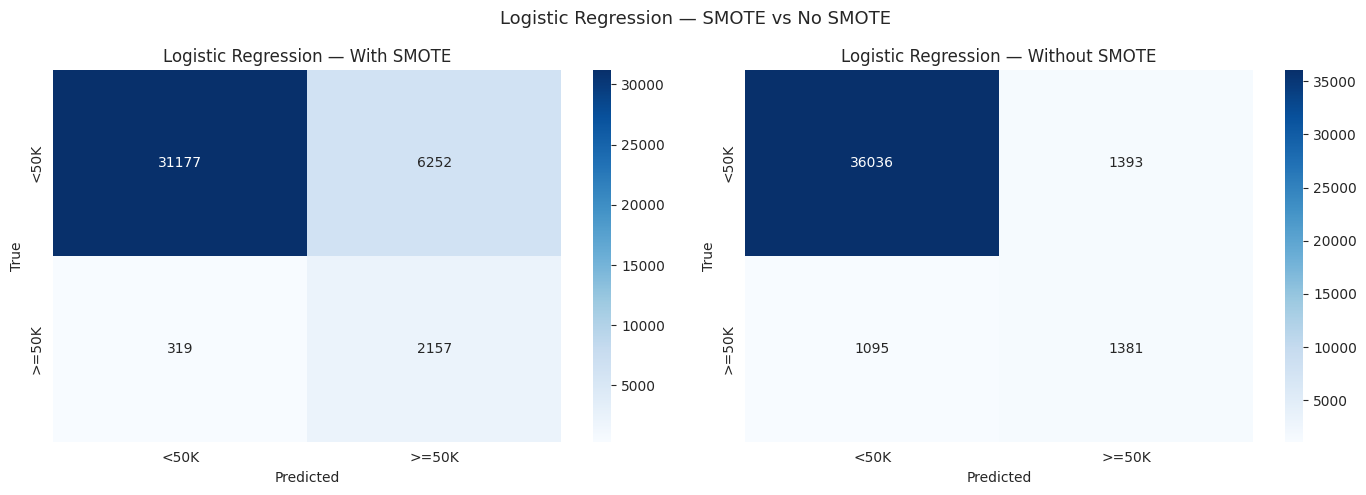

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix for SMOTE model
cm_smote = confusion_matrix(y_te, model_lr.predict(X_te_scaled))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<50K', '>=50K'],
            yticklabels=['<50K', '>=50K'])
axes[0].set_title('Logistic Regression — With SMOTE')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Confusion matrix for No SMOTE model
cm_no_smote = confusion_matrix(y_te, y_pred_no_smote)
sns.heatmap(cm_no_smote, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['<50K', '>=50K'],
            yticklabels=['<50K', '>=50K'])
axes[1].set_title('Logistic Regression — Without SMOTE')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.suptitle('Logistic Regression — SMOTE vs No SMOTE', fontsize=13)
plt.tight_layout()
plt.show()